# Phase 6：论文式 DNN 显式 MPC 方法迁移验证

## 实验问题

本阶段检验 Shokry 等（2025）的核心工作流能否迁移到当前 Chen2020 充电项目：混合初态采样 → 约束 MPC 标签 → 短轨迹展开 → 三隐层 DNN → 裸 DNN 闭环。

这不是原论文 EHM 数值复现。被控模型、状态量、采样周期和约束均沿用本项目已验证的 2RC＋双节点平均热模型。DNN 输出不裁剪，也不调用 Phase 4–5 的安全过滤器。

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs/phase6_paper_method_validation.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

metrics = json.loads((PROJECT_ROOT / "outputs/metrics/phase6_metrics.json").read_text(encoding="utf-8"))
dataset = pd.read_csv(PROJECT_ROOT / "data/phase6_paper_method_validation/paper_teacher_dataset.csv")
selection = pd.read_csv(PROJECT_ROOT / "data/phase6_paper_method_validation/network_selection.csv")
predictions = pd.read_csv(PROJECT_ROOT / "data/phase6_paper_method_validation/offline_predictions.csv")
print("Dataset gate:", metrics["paper_dataset"]["success"])
print("Nominal 25 C gate:", metrics["nominal_25c"]["success"])
print("Phase 6 success:", metrics["success"])

Dataset gate: True
Nominal 25 C gate: False
Phase 6 success: False


## 1. 论文流程与本项目映射

论文 EHM 案例使用 500 个初态、每条轨迹展开 8 个控制步，并以混合试验设计覆盖状态空间。本迁移实验同样尝试 500 个初态，但把状态映射为

\[
x_k=[SOC_k,\ v_{f,k},\ v_{s,k},\ T_{avg,k},\ I_{k-1}],
\]

标签为约束 MPC 在该状态给出的电流 \(I_k^*\)。MPC 仍使用 Phase 3 的 5 min 预测窗口；每个初态只展开前 8 个 5 s 状态—动作对。这一处理避免把“8 个监督样本”误写成只有 40 s 前视的短视控制器。

In [2]:
paper = metrics["configuration"]["paper_method"]
display(pd.Series({
    "attempted initial states": paper["initial_state_count"],
    "unfolded steps per accepted trajectory": paper["trajectory_steps"],
    "Hammersley fraction": paper["hammersley_fraction"],
    "state dimension": len(paper["state_ranges"]),
}, name="declared design").to_frame())
display(pd.DataFrame(paper["state_ranges"], index=["lower", "upper"]).T)

,declared design
attempted initial states,500.0
unfolded steps per accepted trajectory,8.0
Hammersley fraction,0.9
state dimension,5.0


,lower,upper
state_soc,0.1,0.79
state_polarization_fast_v,0.0,0.09
state_polarization_slow_v,0.0,0.09
state_average_temperature_c,25.0,33.40
state_previous_current_a,0.0,10.00


## 2. MPC 教师数据集审计

,result
accepted / attempted,434/500
acceptance [%],86.8
unfolded samples,3472
mean solve time [ms],927.554125
max solve time [ms],5195.5472


,passed
accepted_initial_states,True
teacher_acceptance_fraction,True
trajectory_split_isolation,True
all_splits_nonempty,True
current_labels_bounded,True


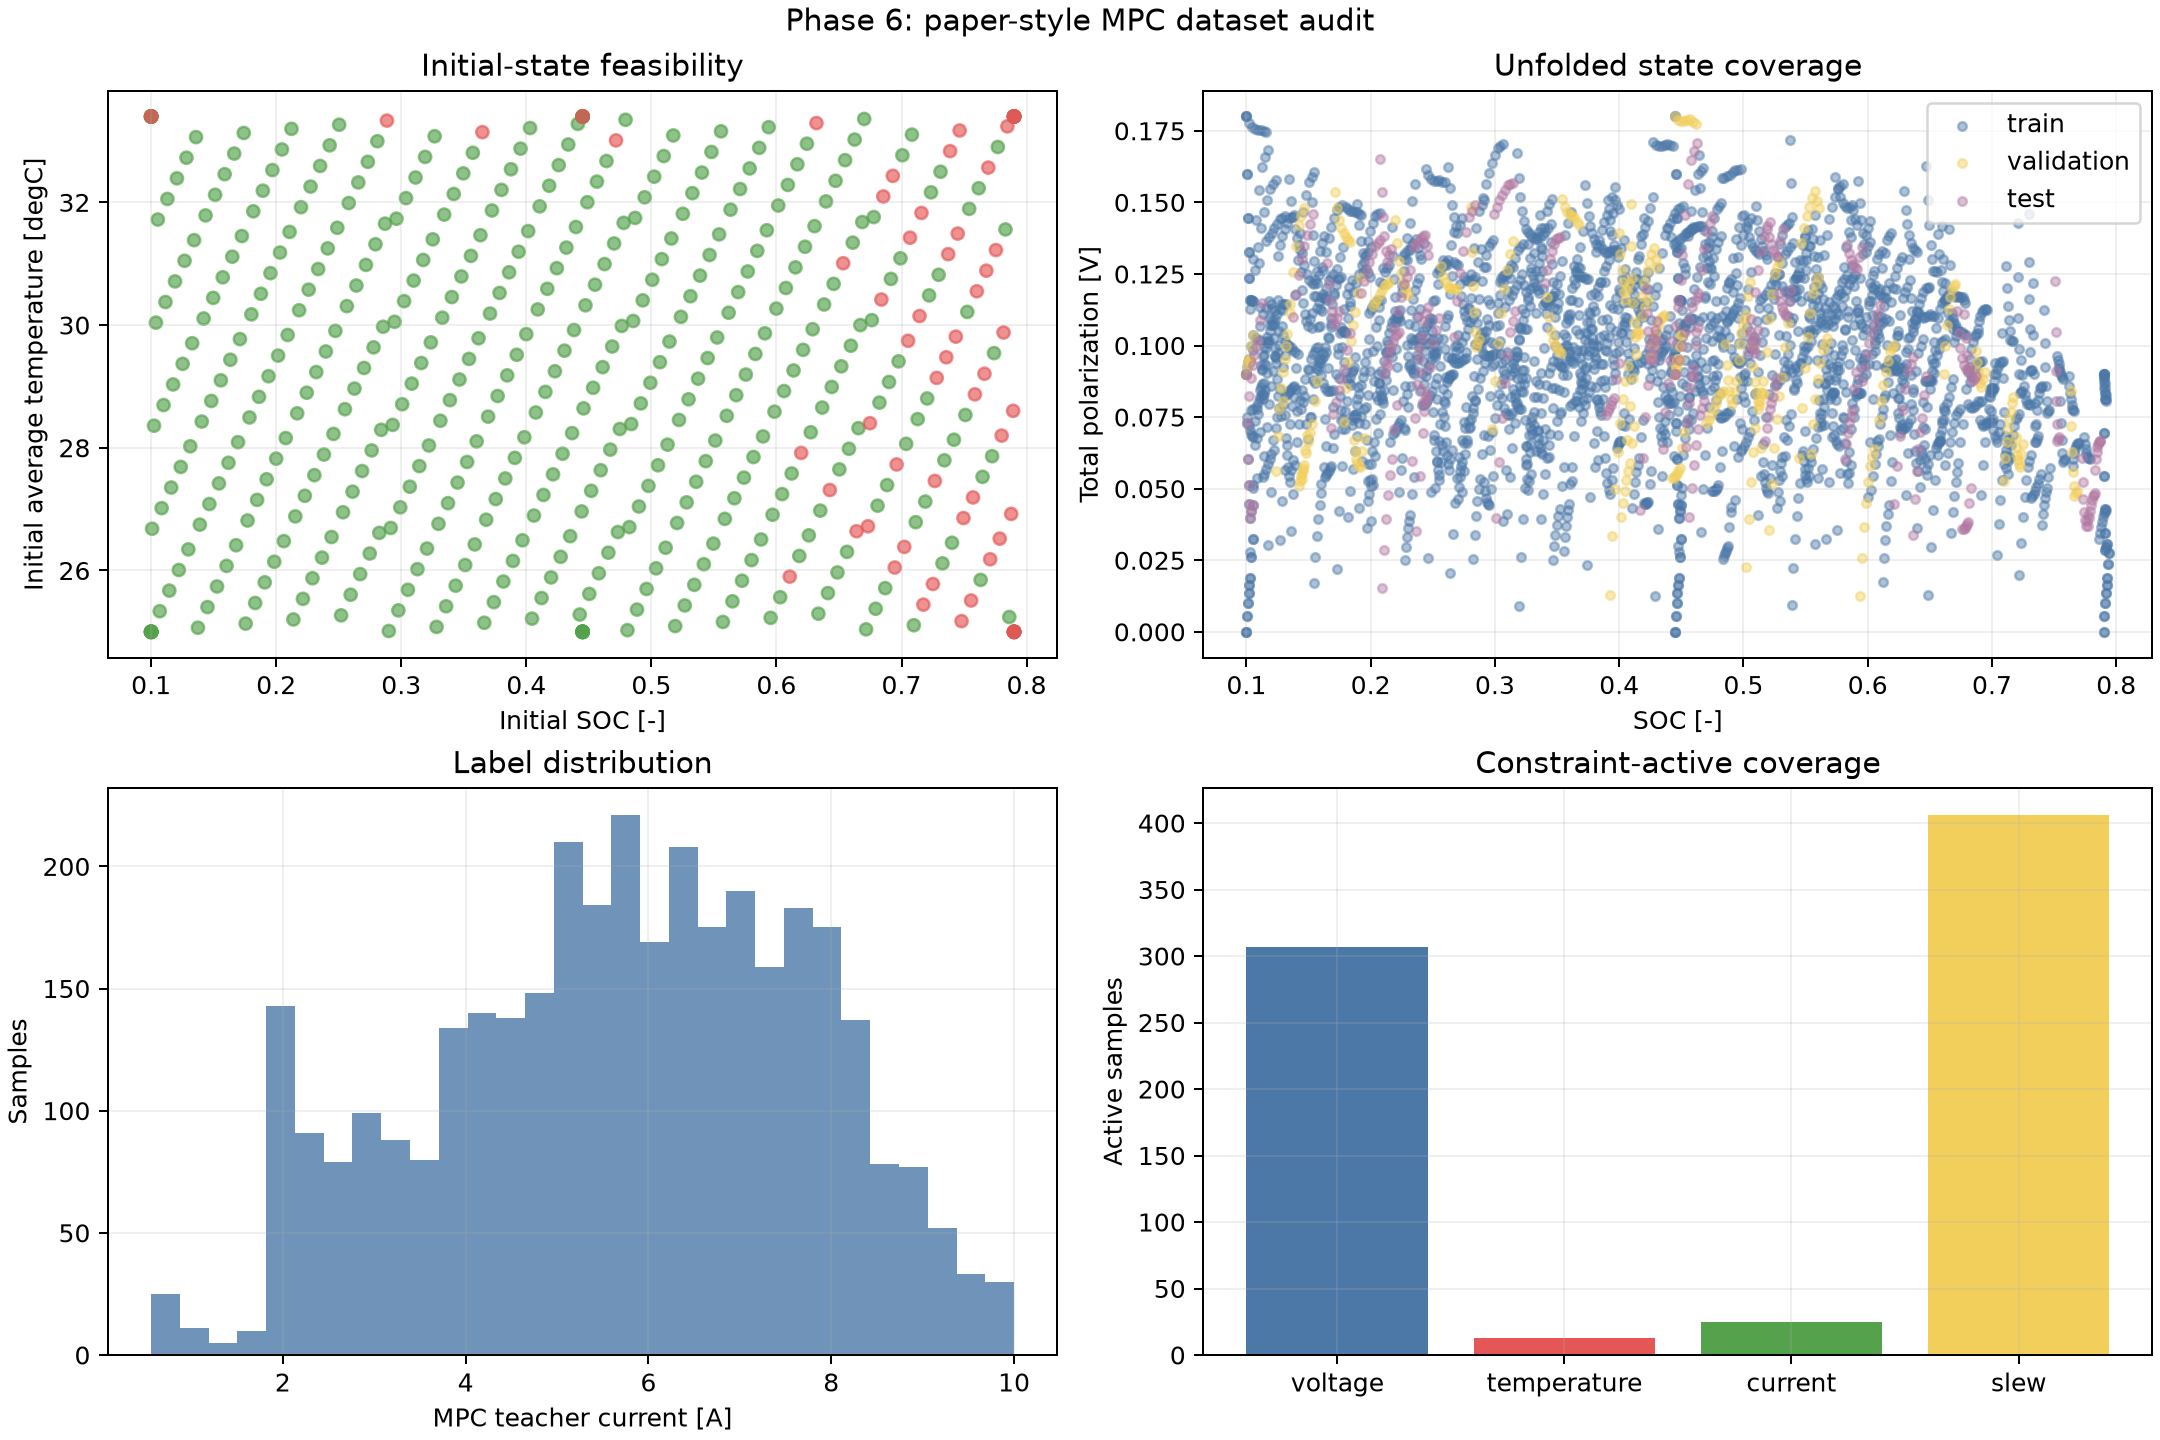

In [3]:
d = metrics["paper_dataset"]
display(pd.Series({
    "accepted / attempted": f'{d["accepted_initial_state_count"]}/{d["attempted_initial_state_count"]}',
    "acceptance [%]": 100 * d["teacher_acceptance_fraction"],
    "unfolded samples": d["unfolded_sample_count"],
    "mean solve time [ms]": d["mean_teacher_solve_time_ms"],
    "max solve time [ms]": d["maximum_teacher_solve_time_ms"],
}, name="result").to_frame())
display(pd.Series(d["checks"], name="passed").to_frame())
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/phase6_paper_dataset_audit.png")))

434/500 个初态得到可接受的 MPC 解，共展开 3472 个样本；整轨迹划分保证相邻时刻不会跨训练、验证和测试集泄漏。数据闸门通过，只代表标签生成过程可用于训练，不代表 DNN 已能复现闭环策略。

## 3. 纯论文式 DNN 的离线结果

,architecture,regularization_alpha,initialization_seed,validation_mae_a,validation_rmse_a,validation_nrmse,optimization_iterations
7,7-5-3,0.0100,22,0.385021,0.553575,0.055357,5000
0,7-5-3,0.0001,11,0.391893,0.560100,0.056010,5000
4,7-5-3,0.0010,22,0.390624,0.562132,0.056213,5000
3,7-5-3,0.0010,11,0.383611,0.565514,0.056551,5000
1,7-5-3,0.0001,22,0.384964,0.567262,0.056726,5000
2,7-5-3,0.0001,33,0.393296,0.574051,0.057405,5000
5,7-5-3,0.0010,33,0.409750,0.576888,0.057689,5000
6,7-5-3,0.0100,11,0.407843,0.577472,0.057747,5000
8,7-5-3,0.0100,33,0.404041,0.587910,0.058791,5000
16,12-8-4,0.0100,22,0.444829,0.658049,0.065805,5000


,sample_count,mae_a,rmse_a,nrmse,maximum_absolute_error_a,bias_a,r2
test,352.0,0.38852,0.56275,0.05627,1.79347,-0.03000,0.93091
train,2776.0,0.35912,0.52936,0.05294,1.92375,0.00019,0.93198
validation,344.0,0.38502,0.55357,0.05536,1.79922,0.01162,0.91308


,selected DNN
architecture,"[5, 7, 5, 3, 1]"
parameters,104
raw outputs below 0 A,0
raw outputs above 10 A,5


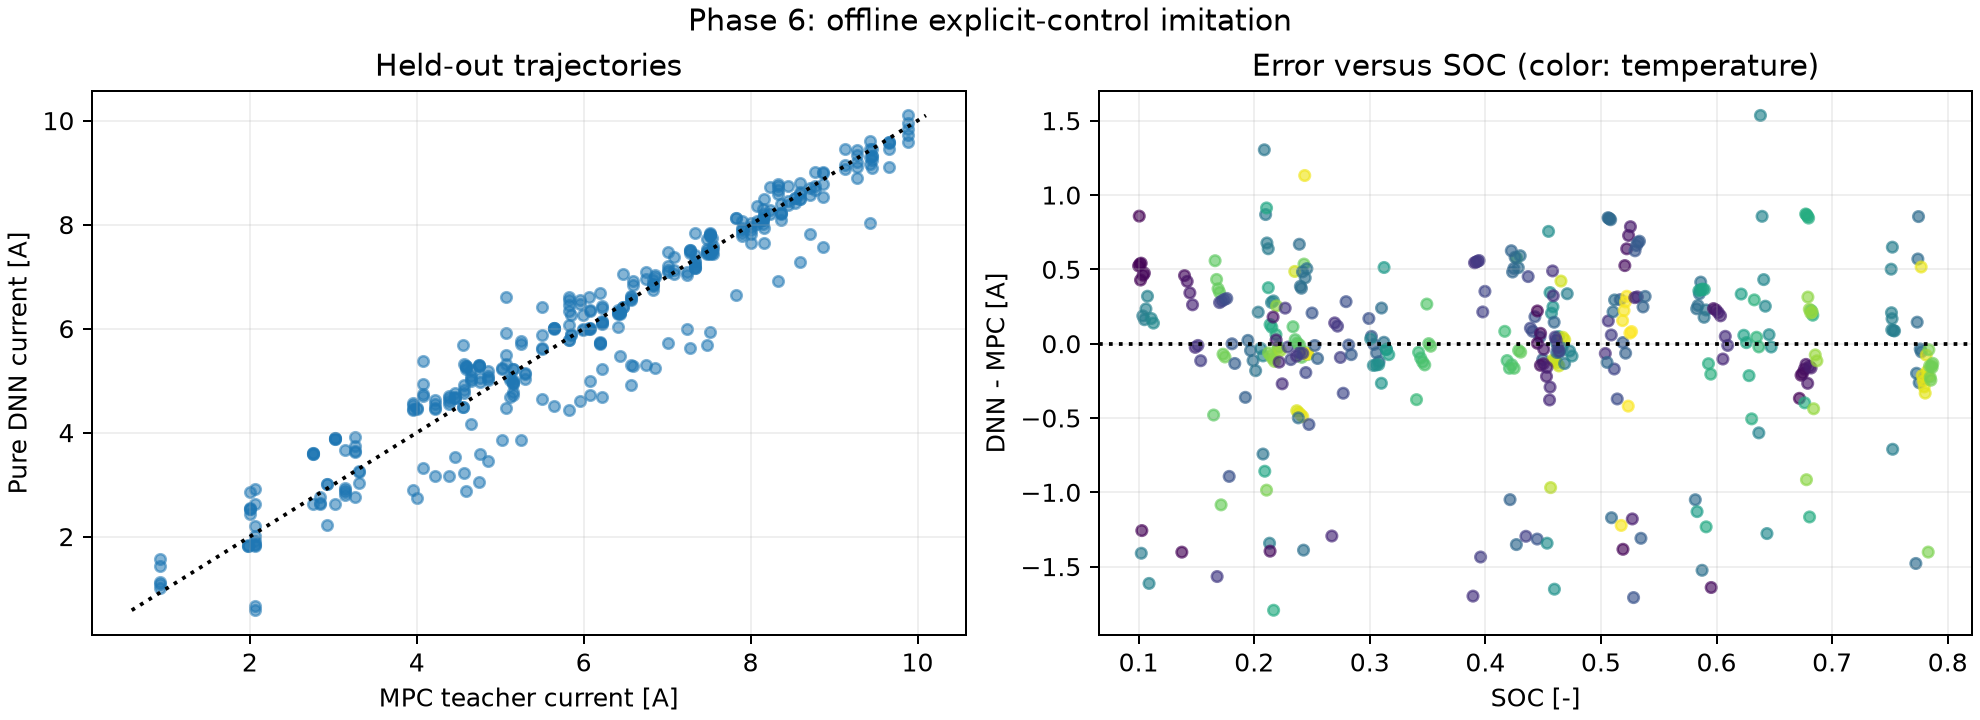

In [4]:
offline = metrics["offline_dnn"]
display(selection.sort_values("validation_rmse_a").head(10))
display(pd.DataFrame(offline["split_metrics"]).T.round(5))
display(pd.Series({
    "architecture": str(offline["architecture"]),
    "parameters": offline["parameter_count"],
    "raw outputs below 0 A": offline["raw_output_below_zero_count"],
    "raw outputs above 10 A": offline["raw_output_above_maximum_count"],
}, name="selected DNN").to_frame())
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/phase6_paper_dnn_offline.png")))

选中网络为 5–7–5–3–1，共 104 个参数。测试 RMSE 为 0.5627 A，按 10 A 量程归一化的 NRMSE 为 5.63%，已经高于预设的 1% 目标。训练集、验证集和测试集误差接近，说明当前主要不是简单的测试集过拟合，而是这组状态—标签映射对当前小网络和数据设计仍然较难。

## 4. 25 ℃ 名义 DFN 闭环与 MPC teacher 对照

,result,required
closed_loop_current_nrmse,False,<= 1%
no_serious_physical_violation,False,True
reached_target_soc,True,True
charge_time_gap,False,<= 2%
inference_speedup,True,>= 100x


,DNN vs MPC
comparison_step_count,603.000000
current_rmse_a,0.772907
current_nrmse,0.077291
charge_time_gap_fraction,0.062208
inference_speedup_over_mpc,8855.545310


,pure DNN on DFN
reached_target_soc,True
final_soc,0.799851
charge_time_min,50.25
maximum_voltage_v,4.142585
maximum_temperature_c,34.872721
minimum_current_a,0.0
maximum_current_a,8.26911
maximum_current_change_a,2.616704
voltage_violation_v,0.0
temperature_violation_c,0.0


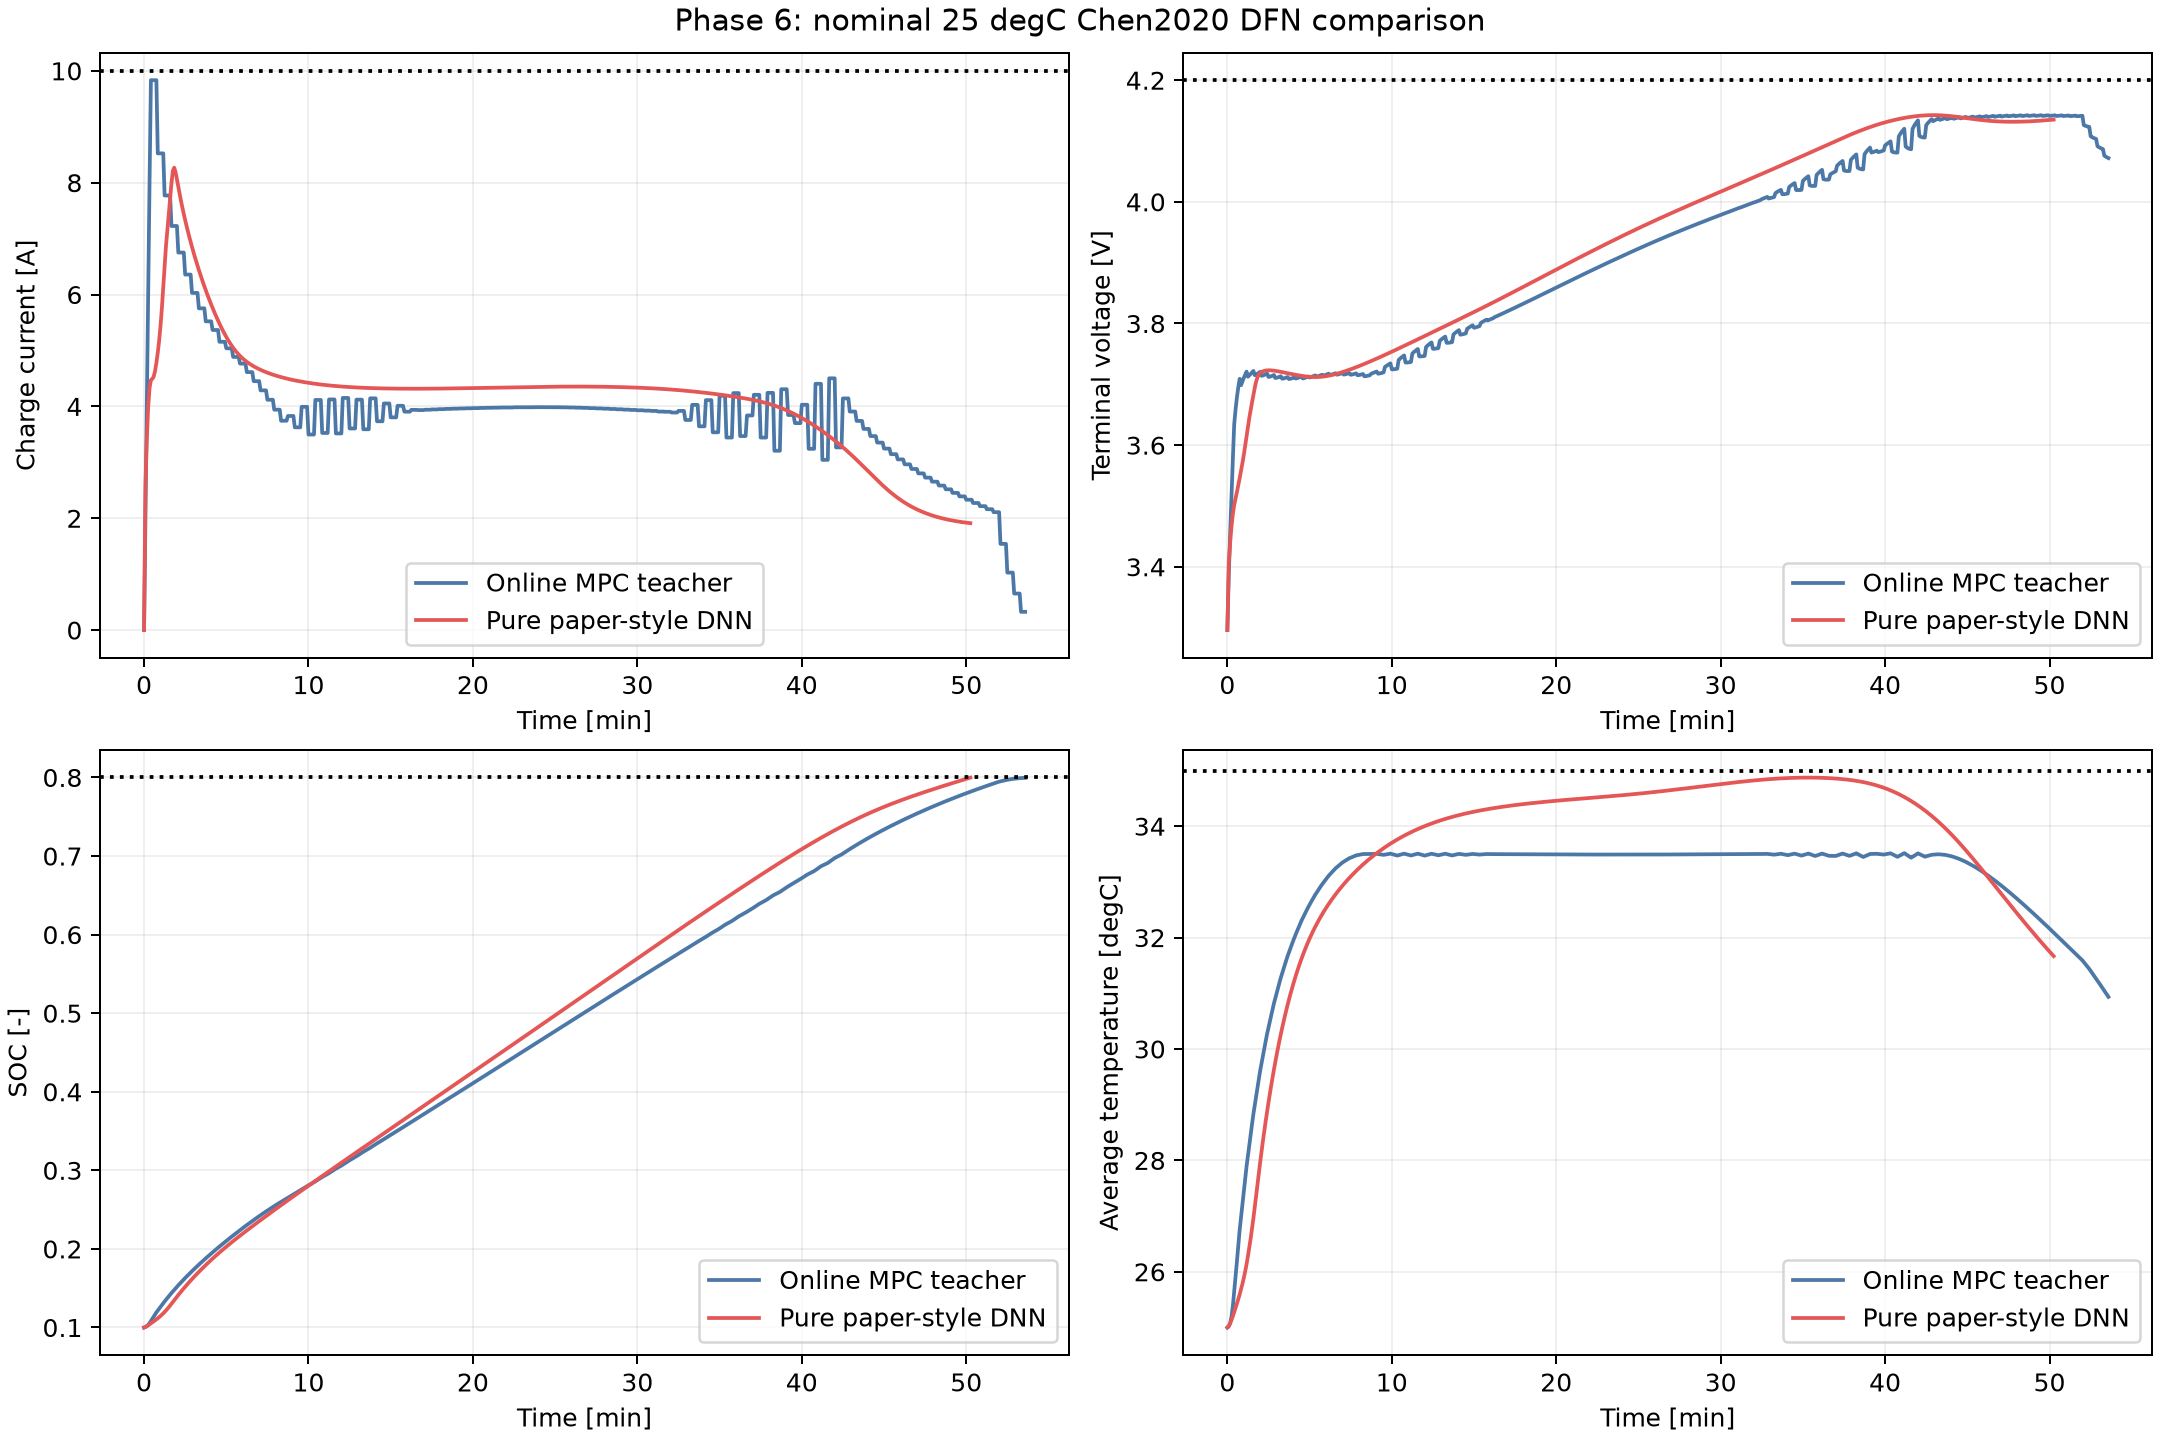

In [5]:
nominal = metrics["nominal_25c"]
display(pd.DataFrame({
    "result": nominal["checks"],
    "required": {
        "closed_loop_current_nrmse": "<= 1%",
        "no_serious_physical_violation": True,
        "reached_target_soc": True,
        "charge_time_gap": "<= 2%",
        "inference_speedup": ">= 100x",
    },
}))
display(pd.Series(nominal["comparison"], name="DNN vs MPC").to_frame())
display(pd.Series(nominal["dfn"], name="pure DNN on DFN").to_frame())
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/phase6_nominal_25c_comparison.png")))

名义门槛未通过：闭环电流 NRMSE 为 7.73%，充电时间相对 MPC 偏差 6.22%，首段最大电流变化 2.6167 A，超过 2 A/5 s 限制。最高电压 4.1426 V、最高平均温度 34.8727 ℃，没有电压或温度越界；平均推理速度约为 MPC 的 8856 倍。

DNN 更早到达 80% SOC 不能解释为性能提升，因为它同时偏离教师电流并违反斜率约束。

## 5. 阶段判定与下一步

In [6]:
display(pd.Series({
    "dataset generation passed": metrics["paper_dataset"]["success"],
    "nominal 25 C passed": metrics["nominal_25c"]["success"],
    "15/25/30 C and Phase 5A": metrics["extended_validation"]["status"],
    "overall Phase 6 passed": metrics["success"],
}, name="gate").to_frame())

,gate
dataset generation passed,True
nominal 25 C passed,False
15/25/30 C and Phase 5A,not_run_nominal_gate_failed
overall Phase 6 passed,False


按照预先登记的顺序，名义工况失败后不运行 15/30 ℃ 和 Phase 5A 压力测试。本轮结论是：**论文式数据生成器已实现并通过审计，但纯 DNN 显式控制律尚未达到迁移验证门槛。**

下一轮应作为 Phase 6B 单独开展，优先分析标签在活跃约束附近的不连续性、增加独立初态覆盖或比较论文同口径训练器；不能通过降低 1%/2% 门槛、加入安全裁剪或使用名义闭环结果反复挑模型来宣称本阶段通过。